In [1]:
import torch 
import torch.fft as fft
import torch.nn as nn
import numpy as np
import h5py
import math
import json
import train
import os
import gc
import matplotlib.pyplot as plt

from mri_utils import mri_encoding, mri_decoding, walsh_smaps, fftc, ifftc, make_acc_mask, quant_complex, quant_tensor, espirit, mri_awgn
from nle import whiten 
from utils import load_data_knee

/home/ee2178/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
kspace, smaps, mask, image = load_data_knee(slice = 25, kspace_root = "../../datasets/fastmri/knee/multicoil_val",)

In [13]:
kspace_w, smaps_w, Sigma, zinv = whiten(ifftc(kspace), smaps)
Sigma.max()

tensor(0.0157)

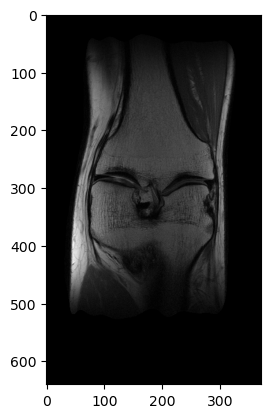

In [4]:
# Inspect new coil combined image with kspace_w and smaps_w
image_w = torch.sum(smaps_w.conj()*kspace_w, dim=1, keepdim=True)
plt.imshow(image_w.abs().detach().cpu()[0,0], cmap = 'gray')

In [5]:
# Generate a mask
Ny, Nx = image.shape[-2], image.shape[-1]
mask = make_acc_mask(
        shape=(Ny, Nx),
        accel=6,
        acs_lines=20
    ).to(image.device)

# plt.imshow(mask.detach().cpu()[0,0])

In [11]:
x_w, smaps_w, Sigma, zinv = whiten(ifftc(mask*kspace), smaps, mask = mask)

In [12]:
Sigma.max()

tensor(0.0064)

In [42]:
acs_mask, (w_start, w_end) = extract_acs_columns(mask)

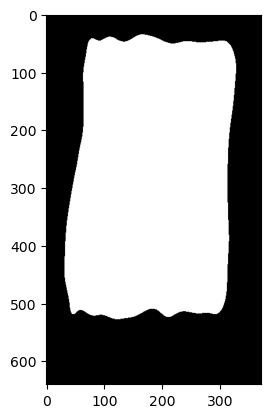

In [12]:
# Inspect new coil combined image with kspace_w and smaps_w

image_w = torch.sum(smaps_w.conj()*x_w, dim=1, keepdim=True)
plt.imshow(Sigma.abs().detach().cpu()[0,0], cmap = 'gray')

In [ ]:
# Sigma is an image of noise powers, pick the highest as it is consistent in the organ mask region. 
smap_root = "../../datasets/fastmri_preprocessed/knee_coil_combined/pd/train"
# Sweep over all fnames in kspace root
# record sigma_max for each sigma
# Form histogram of sigma_max's
sigma_hist = []
for root, dirs, files in os.walk(smap_root):
    # Take file and compute sigma
    for file in files:
        kspace, smaps, mask, gnd_truth = load_data_knee(kspace_fname = file, kspace_root = "../../datasets/fastmri/knee/multicoil_train", smap_root = smap_root)
        for s in range(12, 25):
            _, _, Sigma, _ = whiten(ifftc(kspace[s:s+1, :, :, :]), smaps[s:s+1, :, :, :])
            sigma_hist.append(Sigma.max())

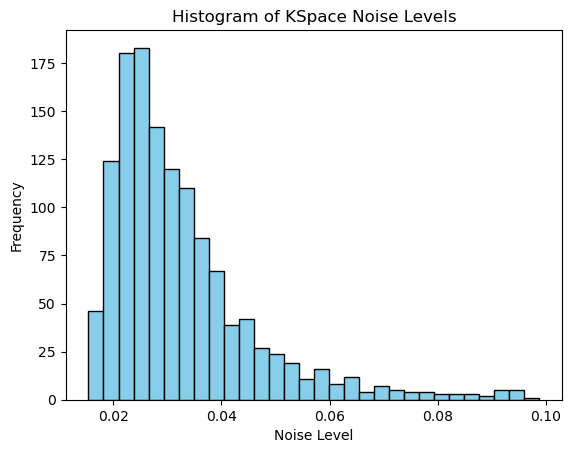

In [4]:
# plot histogram
# Create the histogram
plt.hist(sigma_hist, bins=30, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Noise Level')
plt.ylabel('Frequency')
plt.title('Histogram of KSpace Noise Levels (Validation Set)')

plt.show()

In [39]:
def make_coordinate_grid(H, W, device):
    y = torch.linspace(-1, 1, H, device=device)
    x = torch.linspace(-1, 1, W, device=device)
    yy, xx = torch.meshgrid(y, x, indexing='ij')
    return xx, yy  # shape (H, W)

def polynomial_basis(xx, yy, degree):
    """
    Returns list of basis terms up to given total degree.
    Example for degree=2:
    [1, x, y, x^2, xy, y^2]
    """
    basis = []
    for i in range(degree + 1):
        for j in range(degree + 1 - i):
            basis.append((xx ** i) * (yy ** j))
    return basis  # list of (H, W)

def complex_polynomial_field(
    shape,
    degree=3,
    temperature=0.1,
    centered=True
):
    """
    shape: (B, C, H, W)
    returns: complex tensor (B, C, H, W)
    """
    B, C, H, W = shape
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    xx, yy = make_coordinate_grid(H, W, device)
    basis = polynomial_basis(xx, yy, degree)
    K = len(basis)

    # stack basis → (K, H, W)
    basis_stack = torch.stack(basis, dim=0)

    # random coefficients per batch
    coeff_real = torch.randn(B, K, 1, 1, device=device)
    coeff_imag = torch.randn(B, K, 1, 1, device=device)

    # linear combination
    real = torch.sum(coeff_real * basis_stack.unsqueeze(0), dim=1, keepdim=True)
    imag = torch.sum(coeff_imag * basis_stack.unsqueeze(0), dim=1, keepdim=True)

    # normalize for stability
    def normalize(x):
        x = x - x.mean(dim=(-2, -1), keepdim=True)
        x = x / (x.std(dim=(-2, -1), keepdim=True) + 1e-8)
        return x

    real = normalize(real)
    imag = normalize(imag)

    field = real + 1j * imag  # (B,1,H,W)

    if centered:
        field = 1 + temperature * field
    else:
        field = temperature * field

    field = field.expand(-1, C, -1, -1)
    return field.to(torch.complex64)


def modulate_with_polynomial_field(
    x,
    degree=3,
    temperature=0.1,
    centered=True
):
    """
    x: complex tensor (B, C, H, W)
    """
    assert torch.is_complex(x)

    M = complex_polynomial_field(
        x.shape,
        degree=degree,
        temperature=temperature,
        centered=centered
    )

    return x * M

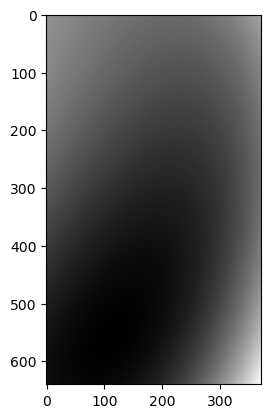

In [65]:
# Generate a sample 

M = complex_polynomial_field(
    smaps.shape,
    degree=3,
    temperature=0.1,
    centered=True
)

# Examine what it would look like if this polynomial field perturbed our smaps
x = torch.sum((M.to(smaps.device)*smaps).conj()*ifftc(kspace), dim = 1, keepdim = True)

plt.imshow(M.abs()[0,0].detach().cpu(), cmap = 'gray')

In [38]:
"""
PyTorch translation of Julia noise-level estimation and multi-coil whitening utilities.

Tensor layout convention: standard PyTorch  (B, C, H, W)
    B – batch, C – coils/channels, H – height, W – width

CDF 9/7 wavelet coefficients are used as a default high-pass filter for
noise estimation.
"""

from __future__ import annotations

import torch
import torch.nn.functional as F
from torch import Tensor
from typing import Optional, Union, List
import os

# ---------------------------------------------------------------------------
# CDF 9/7 high-pass wavelet filter
# ---------------------------------------------------------------------------

cdf97 = torch.tensor(
    [
         0.091271763114,
        -0.057543526229,
        -0.591271763114,
         1.11508705,
        -0.591271763114,
        -0.057543526229,
         0.091271763114,
    ],
    dtype=torch.float64,
)

# Helper function to extract acs columns from a given mask 
def extract_acs_columns(mask: torch.Tensor):
    """
    Extract ACS region when mask has fully sampled columns.

    Parameters
    ----------
    mask : Tensor
        shape (H, W), (B, H, W), or (B, 1, H, W)
        binary mask with fully sampled columns

    Returns
    -------
    acs_mask : same shape as input
    bbox     : (w_start, w_end)
    """

    m = mask

    # reduce to 2D
    if m.dim() == 4:
        m2 = m[0, 0]
    elif m.dim() == 3:
        m2 = m[0]
    else:
        m2 = m

    H, W = m2.shape

    # column is fully sampled if ALL rows are 1
    full_cols = (m2.sum(dim=0) == H)   # shape (W,)

    idx = torch.where(full_cols)[0]

    if len(idx) == 0:
        raise ValueError("No fully sampled columns found.")

    # enforce contiguity (ACS should be central block)
    # find largest contiguous run
    diffs = torch.diff(idx)
    breaks = torch.where(diffs > 1)[0]

    # split into contiguous groups
    groups = []
    start = 0
    for b in breaks.tolist():
        groups.append(idx[start:b+1])
        start = b + 1
    groups.append(idx[start:])

    # pick the group closest to center
    center = W // 2
    def dist_to_center(g):
        return torch.abs(g.float().mean() - center)

    acs_group = min(groups, key=dist_to_center)

    w_start = acs_group[0].item()
    w_end   = acs_group[-1].item() + 1

    # build ACS mask
    acs = torch.zeros_like(m2)
    acs[:, w_start:w_end] = 1

    # restore shape
    if mask.dim() == 4:
        acs = acs.unsqueeze(0).unsqueeze(0).expand_as(mask)
    elif mask.dim() == 3:
        acs = acs.unsqueeze(0).expand_as(mask)

    return acs, (w_start, w_end)
    
# ---------------------------------------------------------------------------
# Internal helpers
# ---------------------------------------------------------------------------

def _real_dtype(x: Tensor) -> torch.dtype:
    if x.is_complex():
        return torch.float32 if x.dtype == torch.complex64 else torch.float64
    return x.dtype


def _eps(x: Tensor) -> float:
    return torch.finfo(_real_dtype(x)).eps

def _separable_conv(x: Tensor, f: Tensor) -> Tensor:
    """
    Depthwise separable 2-D convolution with 1-D filter f.

    Parameters
    ----------
    x : (B, C, H, W) – real or complex
    f : (k,)

    Returns
    -------
    Tensor, same shape as x.
    """
    B, C, H, W = x.shape
    k   = f.shape[0]
    pad = k // 2

    # Merge batch+channel for grouped depthwise conv
    x_pt = x.reshape(1, B * C, H, W)

    f_ = f.to(dtype=_real_dtype(x))
    fh = f_.reshape(1, 1, k, 1).expand(B * C, 1, k, 1).contiguous()
    fw = f_.reshape(1, 1, 1, k).expand(B * C, 1, 1, k).contiguous()

    def _conv_real(t: Tensor) -> Tensor:
        t = F.conv2d(t, fh, padding=(pad, 0), groups=B * C)
        t = F.conv2d(t, fw, padding=(0, pad), groups=B * C)
        return t[..., :H, :W]

    if x.is_complex():
        out = torch.complex(_conv_real(x_pt.real), _conv_real(x_pt.imag))
    else:
        out = _conv_real(x_pt)

    return out.reshape(B, C, H, W)


def _mul_channel(M: Tensor, t: Tensor) -> Tensor:
    """
    Apply a per-batch (C x C) matrix to the channel dimension of t.

    Parameters
    ----------
    M : (B, C, C)
    t : (B, C, H, W)

    Returns
    -------
    Tensor, shape (B, C, H, W)
    """
    B, C, H, W = t.shape
    t_flat = t.reshape(B, C, H * W)          # (B, C, H*W)
    out    = torch.bmm(M, t_flat)            # (B, C, H*W)
    return out.reshape(B, C, H, W)

def _default_filter(x: Tensor) -> Tensor:
    return cdf97.to(device=x.device, dtype=_real_dtype(x))
def ncov_est_undersampled(x: Tensor, mask:Tensor, f: Optional[Tensor] = None) -> Tensor:
    """
    Estimate the inter-channel noise covariance matrix.

    Parameters
    ----------
    x : (B, C, H, W)
    f : 1-D filter, defaults to cdf97

    Returns
    -------
    Tensor, shape (B, C, C)
    """
    if f is None:
        f = _default_filter(x)

    B, C, H, W = x.shape
    
    # Filter each channel independently via depthwise conv
    z = _separable_conv(x, f) / 2.0          # (B, C, H, W)

    # Send to kspace
    z = fftc(z) 

    # Compute NLE on masked kspace
    z = z[:, :, torch.squeeze(mask).bool()]

    # Flatten spatial dims: Z[b, c, n] = filtered pixel n of coil c in batch b
    N_mask = torch.sum(mask)
    Z = z.reshape(B, C, int(N_mask.item()))               # (B, C, N)

    # Sigma[b] = Z[b] @ Z[b]^H / N_mask      shape (B, C, C)
    Sigma = torch.bmm(Z, Z.conj().transpose(-2, -1))   # (B, C, C)

    return Sigma / N_mask               # (B, C, C)

def ncov_est(x: Tensor, f: Optional[Tensor] = None) -> Tensor:
    """
    Estimate the inter-channel noise covariance matrix.

    Parameters
    ----------
    x : (B, C, H, W)
    f : 1-D filter, defaults to cdf97

    Returns
    -------
    Tensor, shape (B, C, C)
    """
    if f is None:
        f = _default_filter(x)

    B, C, H, W = x.shape

    # Filter each channel independently via depthwise conv
    z = _separable_conv(x, f) / 2.0          # (B, C, H, W)

    # Flatten spatial dims: Z[b, c, n] = filtered pixel n of coil c in batch b
    Z = z.reshape(B, C, H * W)               # (B, C, N)

    # Sigma[b] = Z[b] @ Z[b]^H / N_mask      shape (B, C, C)
    Sigma = torch.bmm(Z, Z.conj().transpose(-2, -1))   # (B, C, C)

    # Normalise by number of non-zero pixels per batch element
    mask   = (x.abs().pow(2).sum(dim=1) > 0)           # (B, H, W)
    N_mask = mask.sum(dim=(1, 2)).reshape(B, 1, 1).to(Sigma.dtype)

    return Sigma / N_mask               # (B, C, C)

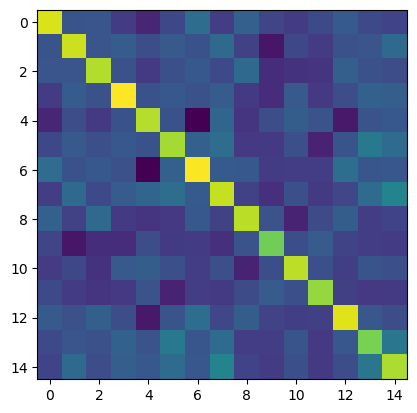

In [42]:
cov_undersamp = ncov_est_undersampled(ifftc(mask*kspace), mask)
cov_undersamp.shape

plt.imshow(cov_undersamp.real.detach().cpu()[0])

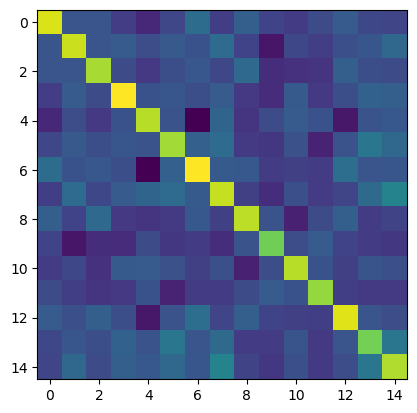

In [43]:
cov = ncov_est(ifftc(kspace))
cov.shape

plt.imshow(cov.real.detach().cpu()[0])

In [53]:
torch.diag(cov[0])

tensor([0.0003+0.j, 0.0003+0.j, 0.0003+0.j, 0.0003+0.j, 0.0003+0.j, 0.0003+0.j, 0.0003+0.j,
        0.0003+0.j, 0.0003+0.j, 0.0002+0.j, 0.0003+0.j, 0.0003+0.j, 0.0003+0.j, 0.0002+0.j,
        0.0003+0.j])

In [54]:
torch.diag(cov_undersamp[0])

tensor([0.0002+0.j, 0.0002+0.j, 0.0002+0.j, 0.0003+0.j, 0.0002+0.j, 0.0002+0.j, 0.0003+0.j,
        0.0002+0.j, 0.0002+0.j, 0.0002+0.j, 0.0002+0.j, 0.0002+0.j, 0.0002+0.j, 0.0002+0.j,
        0.0002+0.j])